In [1]:
import pandas as pd

In [7]:
df=pd.read_csv(r"C:\Users\sefe\Desktop\internet comments\internet.csv")

In [8]:
df.head(5)

,Internet use,Age,Education Level,Marital status,Wealth index,Occupation,Mobile,Electricity,Family Planning,Pregnancy,Individual level Media exposure,Region,Residence,Community Poverity,Community education,Community media exposure
0,0,1,1,3,1,0,0,0,0,0,0,4,0,1,0,0
1,0,3,1,0,1,0,0,0,0,0,0,4,0,1,0,0
2,0,1,1,0,2,0,0,0,0,0,1,4,0,1,0,0
3,0,2,1,0,2,1,0,0,0,0,1,4,0,1,0,0
4,0,2,1,0,2,1,1,0,0,0,1,4,0,1,0,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8650 entries, 0 to 8649
Data columns (total 16 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   Internet use                     8650 non-null   int64
 1   Age                              8650 non-null   int64
 2   Education Level                  8650 non-null   int64
 3   Marital status                   8650 non-null   int64
 4   Wealth index                     8650 non-null   int64
 5   Occupation                       8650 non-null   int64
 6   Mobile                           8650 non-null   int64
 7   Electricity                      8650 non-null   int64
 8   Family Planning                  8650 non-null   int64
 9   Pregnancy                        8650 non-null   int64
 10  Individual level Media exposure  8650 non-null   int64
 11  Region                           8650 non-null   int64
 12  Residence                        8650 non-null  

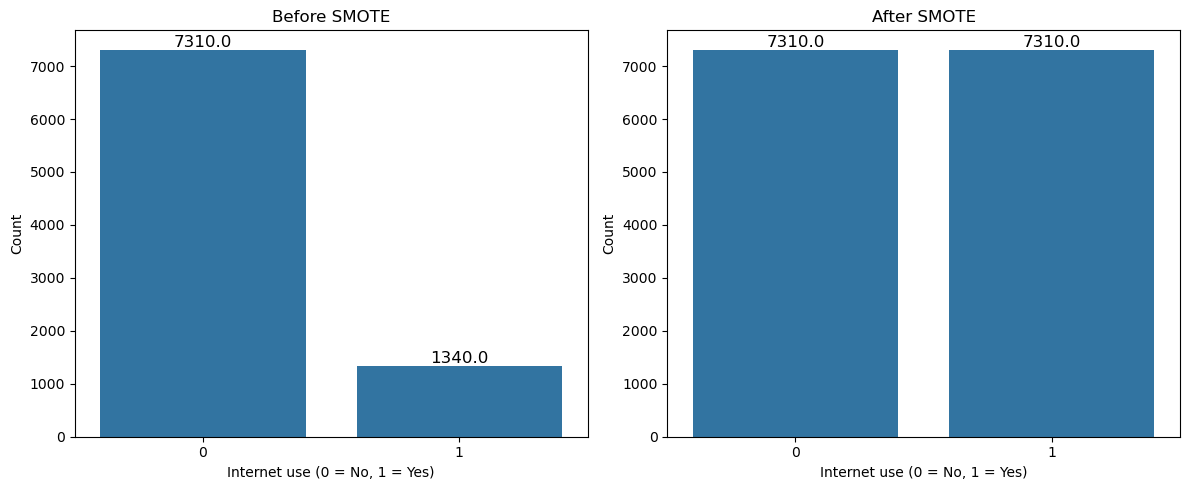


Before SMOTE:
Internet use
0    7310
1    1340
Name: count, dtype: int64

After SMOTE:
Internet use
0    7310
1    7310
Name: count, dtype: int64


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE

# Load data
df=pd.read_csv(r"C:\Users\sefe\Desktop\internet comments\internet.csv")# Separate features and target
X = df.drop("Internet use", axis=1)
y = df["Internet use"]

# Apply SMOTE
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)

# Prepare figure
plt.figure(figsize=(12, 5))

# ----------------------------------------------------------
# BEFORE SMOTE
# ----------------------------------------------------------
plt.subplot(1, 2, 1)
ax1 = sns.countplot(x=y)
plt.title("Before SMOTE")
plt.xlabel("Internet use (0 = No, 1 = Yes)")
plt.ylabel("Count")

# Add counts on top of bars
for p in ax1.patches:
    ax1.annotate(
        f"{p.get_height()}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom', fontsize=12
    )

# ----------------------------------------------------------
# AFTER SMOTE
# ----------------------------------------------------------
plt.subplot(1, 2, 2)
ax2 = sns.countplot(x=y_res)
plt.title("After SMOTE")
plt.xlabel("Internet use (0 = No, 1 = Yes)")
plt.ylabel("Count")

# Add counts on top of bars
for p in ax2.patches:
    ax2.annotate(
        f"{p.get_height()}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom', fontsize=12
    )

plt.tight_layout()
plt.show()

# Print class counts
print("\nBefore SMOTE:")
print(y.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_res).value_counts())

Python: 3.12.4 | packaged by Anaconda, Inc. | (main, Jun 18 2024, 15:03:56) [MSC v.1929 64 bit (AMD64)]
pandas: 2.2.2
numpy: 1.26.4
scikit-learn: 1.4.2
xgboost: 3.1.2
imbalanced-learn: 0.12.3
[Before SMOTE] Logistic Regression: best CV AUC=0.8939, test AUC=0.9012, params={'clf__C': 0.1}
[Before SMOTE] Decision Tree: best CV AUC=0.8831, test AUC=0.8949, params={'clf__max_depth': 5, 'clf__min_samples_leaf': 10}
[Before SMOTE] Random Forest: best CV AUC=0.8961, test AUC=0.9073, params={'clf__max_depth': 10, 'clf__n_estimators': 200}
[Before SMOTE] Gradient Boosting: best CV AUC=0.8994, test AUC=0.9030, params={'clf__learning_rate': 0.1, 'clf__max_depth': 2, 'clf__n_estimators': 200}
[Before SMOTE] KNN: best CV AUC=0.8626, test AUC=0.8765, params={'clf__n_neighbors': 9}
[Before SMOTE] SVM: best CV AUC=0.8906, test AUC=0.8967, params={'clf__C': 10, 'clf__kernel': 'linear'}
[Before SMOTE] Naive Bayes: best CV AUC=0.8686, test AUC=0.8838, params={'clf__var_smoothing': 1e-11}
[Before SMOTE] XG

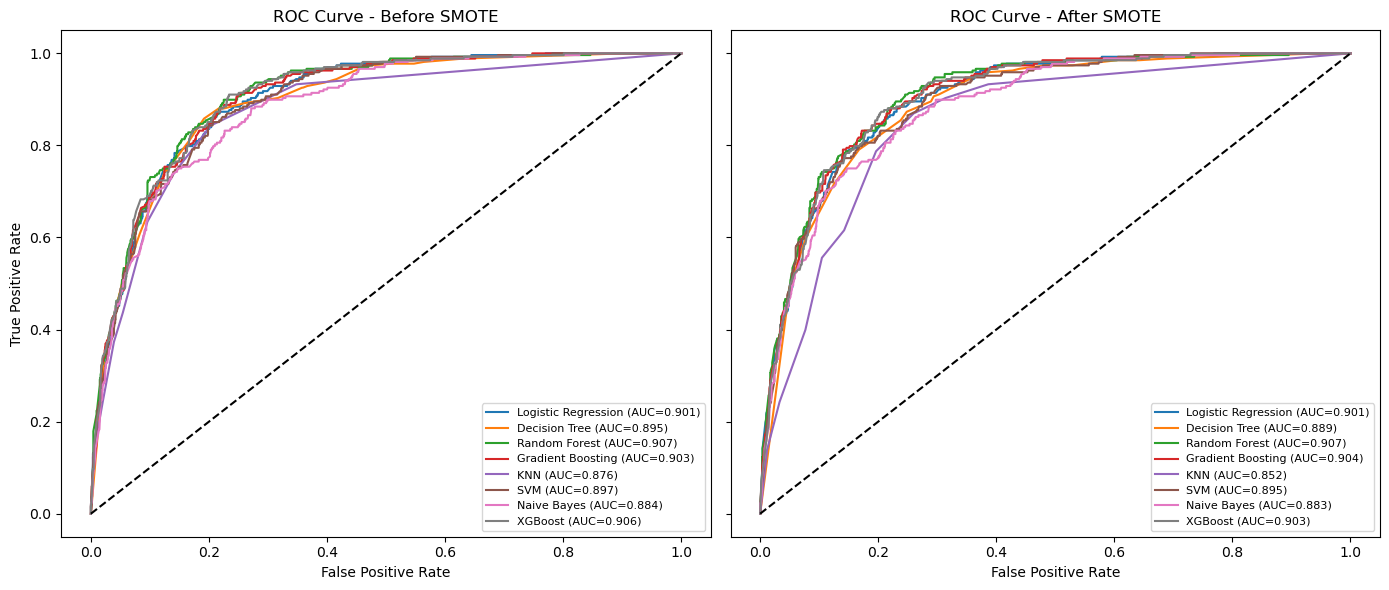


===== MODEL PERFORMANCE BEFORE SMOTE (tuned) =====
                  Model  Accuracy  Precision    Recall  Specificity  F1 Score  \
0  Logistic Regression  0.879191   0.678788  0.417910     0.963748  0.517321   
1        Decision Tree  0.879191   0.732283  0.347015     0.976744  0.470886   
2        Random Forest  0.879191   0.690323  0.399254     0.967168  0.505910   
3    Gradient Boosting  0.878035   0.650794  0.458955     0.954856  0.538293   
4                  KNN  0.867052   0.596939  0.436567     0.945964  0.504310   
5                  SVM  0.875145   0.649425  0.421642     0.958276  0.511312   
6          Naive Bayes  0.755491   0.373984  0.858209     0.736662  0.520951   
7              XGBoost  0.877457   0.645833  0.462687     0.953488  0.539130   

    AUC ROC  
0  0.901227  
1  0.894866  
2  0.907273  
3  0.902995  
4  0.876479  
5  0.896663  
6  0.883828  
7  0.905702  

===== MODEL PERFORMANCE AFTER SMOTE (tuned) =====
                  Model  Accuracy  Precision    R

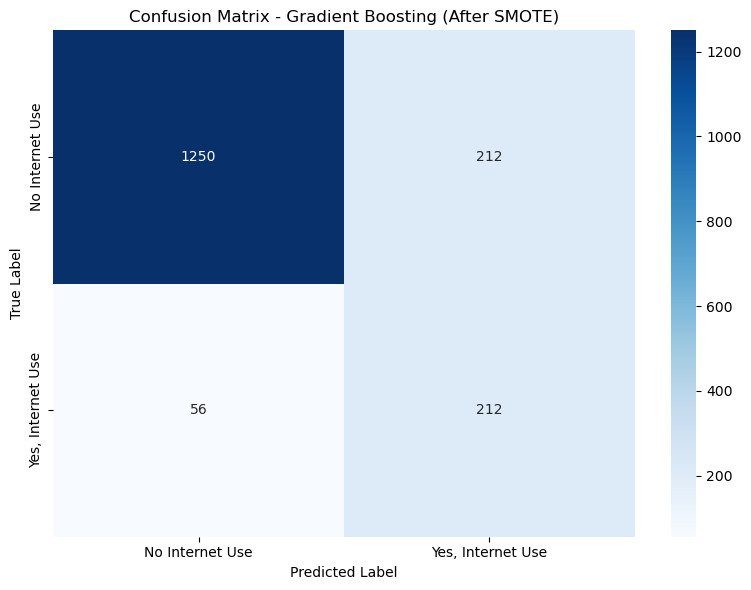


===== FEATURE IMPORTANCE (impurity_importance) =====
            Model                         Feature  Importance     Importance_Type
Gradient Boosting                 Education Level    0.483859 impurity_importance
Gradient Boosting                          Region    0.132190 impurity_importance
Gradient Boosting                          Mobile    0.119650 impurity_importance
Gradient Boosting                  Marital status    0.060907 impurity_importance
Gradient Boosting        Community media exposure    0.054138 impurity_importance
Gradient Boosting Individual level Media exposure    0.045172 impurity_importance
Gradient Boosting                             Age    0.040689 impurity_importance
Gradient Boosting             Community education    0.023782 impurity_importance
Gradient Boosting              Community Poverity    0.018388 impurity_importance
Gradient Boosting                      Occupation    0.011100 impurity_importance
Gradient Boosting                    Wealth 

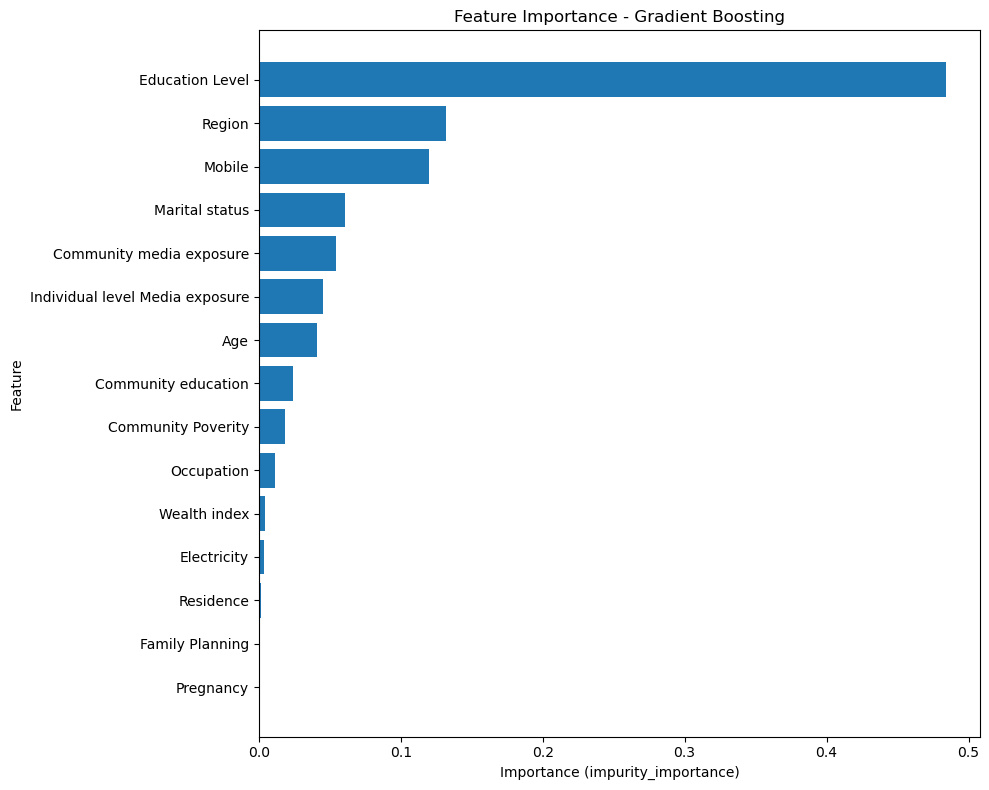

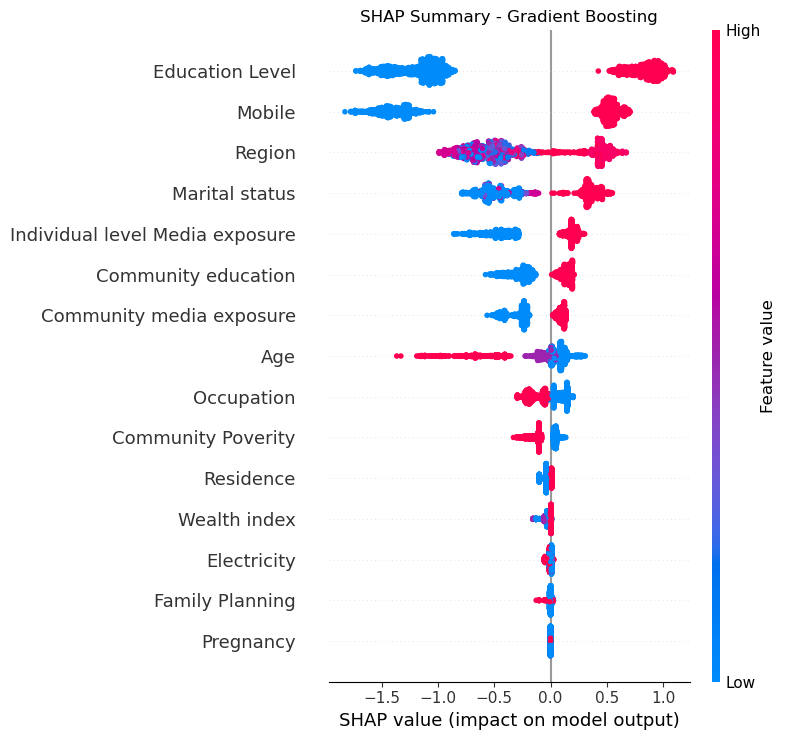

In [11]:
import sys
import pandas as pd
import numpy as np
import sklearn
import xgboost
import imblearn
import shap

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score, classification_report, confusion_matrix
)
from sklearn.inspection import permutation_importance

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
TEST_SIZE = 0.20

print("Python:", sys.version)
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("xgboost:", xgboost.__version__)
print("imbalanced-learn:", imblearn.__version__)

# ---------------------------------------------------------------
# Load data
# ---------------------------------------------------------------
df=pd.read_csv(r"C:\Users\sefe\Desktop\internet comments\internet.csv")
WEIGHT_COL = "weight"  # rename to match your DHS sampling-weight column, e.g. "v005_norm"
has_weights = WEIGHT_COL in df.columns

sample_weight = None
if has_weights:
    sample_weight = df[WEIGHT_COL].to_numpy()
    df = df.drop(columns=[WEIGHT_COL])

X = df.drop("Internet use", axis=1)
y = df["Internet use"]

# ---------------------------------------------------------------
# Train-test split (80/20)
# ---------------------------------------------------------------
if has_weights:
    X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
        X, y, sample_weight, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
    )
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
    )
    w_train, w_test = None, None

# ---------------------------------------------------------------
# Models
# ---------------------------------------------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True, random_state=RANDOM_STATE),
    "Naive Bayes": GaussianNB(),
    "XGBoost": XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE),
}

MODELS_ACCEPTING_SAMPLE_WEIGHT = {
    "Logistic Regression", "Decision Tree", "Random Forest",
    "Gradient Boosting", "SVM", "XGBoost",
}

TREE_MODELS = {"Decision Tree", "Random Forest", "Gradient Boosting", "XGBoost"}

param_grids = {
    "Logistic Regression": {"clf__C": [0.01, 0.1, 1, 10]},
    "Decision Tree": {"clf__max_depth": [3, 5, 10, None], "clf__min_samples_leaf": [1, 5, 10]},
    "Random Forest": {"clf__n_estimators": [100, 200], "clf__max_depth": [5, 10, None]},
    "Gradient Boosting": {"clf__n_estimators": [100, 200], "clf__learning_rate": [0.01, 0.1], "clf__max_depth": [2, 3, 5]},
    "KNN": {"clf__n_neighbors": [3, 5, 7, 9]},
    "SVM": {"clf__C": [0.1, 1, 10], "clf__kernel": ["rbf", "linear"]},
    "Naive Bayes": {"clf__var_smoothing": np.logspace(-11, -7, 5)},
    "XGBoost": {"clf__n_estimators": [100, 200], "clf__max_depth": [3, 5], "clf__learning_rate": [0.01, 0.1]},
}

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)


def evaluate_with_specificity(y_true, y_pred, y_prob_pos):
    cm = confusion_matrix(y_true, y_pred)
    TN, FP, FN, TP = cm.ravel()

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    specificity = TN / (TN + FP) if (TN + FP) > 0 else np.nan
    auc_score = roc_auc_score(y_true, y_prob_pos)

    return accuracy, precision, recall, specificity, f1, auc_score, cm


def get_fit_params(name, w_train):
    if w_train is None or name not in MODELS_ACCEPTING_SAMPLE_WEIGHT:
        return {}
    return {"clf__sample_weight": w_train}


def get_feature_importance(name, fitted_pipeline, feature_names, X_bg, y_bg):
    clf = fitted_pipeline.named_steps["clf"]

    if hasattr(clf, "feature_importances_"):
        values = clf.feature_importances_
        kind = "impurity_importance"
    elif hasattr(clf, "coef_"):
        values = np.abs(clf.coef_).ravel()
        kind = "abs_coefficient"
    else:
        perm = permutation_importance(
            fitted_pipeline, X_bg, y_bg, n_repeats=10,
            random_state=RANDOM_STATE, scoring="roc_auc", n_jobs=-1
        )
        values = perm.importances_mean
        kind = "permutation_importance"

    imp_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": values,
        "Importance_Type": kind,
    }).sort_values("Importance", ascending=False).reset_index(drop=True)
    imp_df.insert(0, "Model", name)
    return imp_df


def get_shap_values(name, fitted_pipeline, X_train_raw, X_test_raw, max_background=100):
    """
    Compute SHAP values for the final selected model, using the explainer
    that matches the model family. Data is passed through the pipeline's
    'scaler' step (the same transform the classifier sees at predict time)
    before being handed to SHAP; the SMOTE step, if present, is fit-only
    and never applied at transform/predict time.
    """
    clf = fitted_pipeline.named_steps["clf"]
    scaler_step = fitted_pipeline.named_steps["scaler"]

    X_train_t = pd.DataFrame(scaler_step.transform(X_train_raw), columns=X_train_raw.columns)
    X_test_t = pd.DataFrame(scaler_step.transform(X_test_raw), columns=X_test_raw.columns)

    if name in TREE_MODELS:
        explainer = shap.TreeExplainer(clf)
        shap_values = explainer.shap_values(X_test_t)
        if isinstance(shap_values, list):  # some tree explainers return [class0, class1]
            shap_values = shap_values[1]
    elif name == "Logistic Regression":
        background = shap.sample(X_train_t, min(max_background, len(X_train_t)), random_state=RANDOM_STATE)
        explainer = shap.LinearExplainer(clf, background)
        shap_values = explainer.shap_values(X_test_t)
    else:
        background = shap.sample(X_train_t, min(max_background, len(X_train_t)), random_state=RANDOM_STATE)
        explainer = shap.Explainer(clf.predict_proba, background)
        shap_values = explainer(X_test_t)[:, :, 1].values

    return shap_values, X_test_t


# ---------------------------------------------------------------
# Before SMOTE
# ---------------------------------------------------------------
results_before = []
tuning_log_before = []
best_models_before = {}
roc_before = []

for name, model in models.items():
    pipe = ImbPipeline([
        ("scaler", StandardScaler()),
        ("clf", model),
    ])
    search = GridSearchCV(pipe, param_grids[name], scoring="roc_auc",
                           cv=cv, n_jobs=-1, refit=True)
    search.fit(X_train, y_train, **get_fit_params(name, w_train))

    best_models_before[name] = search.best_estimator_
    tuning_log_before.append({"Model": name, "Best_CV_AUC": search.best_score_,
                               "Best_Params": search.best_params_})

    y_pred = search.predict(X_test)
    y_prob = search.predict_proba(X_test)

    accuracy, precision, recall, specificity, f1, auc_score, cm = evaluate_with_specificity(
        y_test, y_pred, y_prob[:, 1]
    )
    fpr, tpr, _ = roc_curve(y_test, y_prob[:, 1])
    roc_before.append((name, fpr, tpr, auc_score))

    results_before.append([name, accuracy, precision, recall, specificity, f1, auc_score])
    print(f"[Before SMOTE] {name}: best CV AUC={search.best_score_:.4f}, "
          f"test AUC={auc_score:.4f}, params={search.best_params_}")

# ---------------------------------------------------------------
# After SMOTE
# ---------------------------------------------------------------
results_after = []
tuning_log_after = []
best_models_after = {}
roc_after = []

for name, model in models.items():
    pipe = ImbPipeline([
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
        ("clf", model),
    ])
    search = GridSearchCV(pipe, param_grids[name], scoring="roc_auc",
                           cv=cv, n_jobs=-1, refit=True)
    search.fit(X_train, y_train)

    best_models_after[name] = search.best_estimator_
    tuning_log_after.append({"Model": name, "Best_CV_AUC": search.best_score_,
                              "Best_Params": search.best_params_})

    y_pred = search.predict(X_test)
    y_prob = search.predict_proba(X_test)

    accuracy, precision, recall, specificity, f1, auc_score, cm = evaluate_with_specificity(
        y_test, y_pred, y_prob[:, 1]
    )
    fpr, tpr, _ = roc_curve(y_test, y_prob[:, 1])
    roc_after.append((name, fpr, tpr, auc_score))

    results_after.append([name, accuracy, precision, recall, specificity, f1, auc_score])
    print(f"[After SMOTE] {name}: best CV AUC={search.best_score_:.4f}, "
          f"test AUC={auc_score:.4f}, params={search.best_params_}")

# ---------------------------------------------------------------
# Combined ROC figure
# ---------------------------------------------------------------
fig, (ax_before, ax_after) = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

for name, fpr, tpr, auc_score in roc_before:
    ax_before.plot(fpr, tpr, label=f"{name} (AUC={auc_score:.3f})")
ax_before.plot([0, 1], [0, 1], 'k--')
ax_before.set_title("ROC Curve - Before SMOTE")
ax_before.set_xlabel("False Positive Rate")
ax_before.set_ylabel("True Positive Rate")
ax_before.legend(fontsize=8)

for name, fpr, tpr, auc_score in roc_after:
    ax_after.plot(fpr, tpr, label=f"{name} (AUC={auc_score:.3f})")
ax_after.plot([0, 1], [0, 1], 'k--')
ax_after.set_title("ROC Curve - After SMOTE")
ax_after.set_xlabel("False Positive Rate")
ax_after.legend(fontsize=8)

plt.tight_layout()
plt.savefig("roc_before_after_smote.png", dpi=300, bbox_inches="tight")
plt.show()

# ---------------------------------------------------------------
# Results tables
# ---------------------------------------------------------------
metric_cols = ["Model", "Accuracy", "Precision", "Recall", "Specificity", "F1 Score", "AUC ROC"]
results_before_df = pd.DataFrame(results_before, columns=metric_cols)
results_after_df = pd.DataFrame(results_after, columns=metric_cols)

tuning_log_before_df = pd.DataFrame(tuning_log_before)
tuning_log_after_df = pd.DataFrame(tuning_log_after)

print("\n===== MODEL PERFORMANCE BEFORE SMOTE (tuned) =====\n", results_before_df)
print("\n===== MODEL PERFORMANCE AFTER SMOTE (tuned) =====\n", results_after_df)

results_comparison_df = results_before_df.merge(
    results_after_df, on="Model", suffixes=("_Before", "_After")
)
print("\n===== COMBINED BEFORE/AFTER SMOTE COMPARISON =====\n",
      results_comparison_df.to_string(index=False))

results_comparison_df.to_csv("model_comparison_before_after_smote.csv", index=False)
tuning_log_before_df.to_csv("tuning_log_before_smote.csv", index=False)
tuning_log_after_df.to_csv("tuning_log_after_smote.csv", index=False)

# ---------------------------------------------------------------
# Final model selection (by cross-validated AUC, not test-set AUC)
# ---------------------------------------------------------------
SELECTION_METRIC = "Best_CV_AUC"
best_tuning_row = tuning_log_after_df.sort_values(SELECTION_METRIC, ascending=False).iloc[0]
print(f"\nFinal model selected (post-SMOTE, ranked by {SELECTION_METRIC}): {best_tuning_row['Model']}")
print(tuning_log_after_df.sort_values(SELECTION_METRIC, ascending=False).to_string(index=False))

final_model_name = best_tuning_row["Model"]
final_model = best_models_after[final_model_name]

# ---------------------------------------------------------------
# Final model evaluation
# ---------------------------------------------------------------
y_pred_final = final_model.predict(X_test)
y_prob_final = final_model.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred_final)
TN, FP, FN, TP = cm.ravel()

accuracy = accuracy_score(y_test, y_pred_final)
precision = precision_score(y_test, y_pred_final, zero_division=0)
recall = recall_score(y_test, y_pred_final, zero_division=0)
f1 = f1_score(y_test, y_pred_final, zero_division=0)
auc_score = roc_auc_score(y_test, y_prob_final)
specificity = TN / (TN + FP) if (TN + FP) > 0 else np.nan

print("\n==============================================")
print("FINAL MODEL PERFORMANCE")
print("==============================================")
print(f"Model:        {final_model_name}")
print(f"Accuracy:     {accuracy:.4f}")
print(f"Precision:    {precision:.4f}")
print(f"Recall:       {recall:.4f}")
print(f"Specificity:  {specificity:.4f}")
print(f"F1-score:     {f1:.4f}")
print(f"ROC-AUC:      {auc_score:.4f}")

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_final,
        target_names=["No Internet Use", "Yes, Internet Use"],
        digits=4
    )
)

# ---------------------------------------------------------------
# Confusion matrix heatmap for the final (best) model
# ---------------------------------------------------------------
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=["No Internet Use", "Yes, Internet Use"],
    yticklabels=["No Internet Use", "Yes, Internet Use"],
)
plt.title(f"Confusion Matrix - {final_model_name} (After SMOTE)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("final_model_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

# ---------------------------------------------------------------
# Feature importance for the final model (method matched to model type)
# ---------------------------------------------------------------
feature_names = X_train.columns.tolist()
importance_df = get_feature_importance(
    final_model_name, final_model, feature_names, X_test, y_test
)
print(f"\n===== FEATURE IMPORTANCE ({importance_df['Importance_Type'].iloc[0]}) =====")
print(importance_df.to_string(index=False))
importance_df.to_csv("final_model_feature_importance.csv", index=False)

plt.figure(figsize=(10, 8))
plot_df = importance_df.sort_values("Importance", ascending=True)
plt.barh(plot_df["Feature"], plot_df["Importance"])
plt.xlabel(f"Importance ({importance_df['Importance_Type'].iloc[0]})")
plt.ylabel("Feature")
plt.title(f"Feature Importance - {final_model_name}")
plt.tight_layout()
plt.savefig("final_model_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

# ---------------------------------------------------------------
# Feature importance for every tuned model, before and after SMOTE
# ---------------------------------------------------------------
all_importances = []
for name, fitted in best_models_before.items():
    imp = get_feature_importance(name, fitted, feature_names, X_test, y_test)
    imp["Stage"] = "Before SMOTE"
    all_importances.append(imp)
for name, fitted in best_models_after.items():
    imp = get_feature_importance(name, fitted, feature_names, X_test, y_test)
    imp["Stage"] = "After SMOTE"
    all_importances.append(imp)

all_importances_df = pd.concat(all_importances, ignore_index=True)
all_importances_df.to_csv("all_models_feature_importance.csv", index=False)

# ---------------------------------------------------------------
# SHAP summary plot for the final model
# ---------------------------------------------------------------
shap_values, X_test_transformed = get_shap_values(
    final_model_name, final_model, X_train, X_test
)

plt.figure()
shap.summary_plot(shap_values, X_test_transformed, show=False)
plt.title(f"SHAP Summary - {final_model_name}")
plt.tight_layout()
plt.savefig("final_model_shap_summary.png", dpi=300, bbox_inches="tight")
plt.show()

In [1]:
import pandas as pd

file_path = r"C:\Users\sefe\Desktop\internet comments\internet.csv"
df = pd.read_csv(file_path)

rows = []

for col in df.columns:
    freq = df[col].value_counts(dropna=False).sort_index()

    for value, count in freq.items():
        rows.append({
            "Variable": col,
            "Code": value,
            "Frequency": count,
            "Percent": round((count / len(df)) * 100, 2)
        })

coding_table = pd.DataFrame(rows)

print(coding_table.to_string(index=False))

coding_table.to_csv(
    r"C:\Users\sefe\Desktop\internet comments\all_variable_coding.csv",
    index=False
)

                       Variable  Code  Frequency  Percent
                   Internet use     0       7310    84.51
                   Internet use     1       1340    15.49
                            Age     1       4993    57.72
                            Age     2       2332    26.96
                            Age     3       1325    15.32
                Education Level     1       5213    60.27
                Education Level     2       3437    39.73
                 Marital status     0       4131    47.76
                 Marital status     1        154     1.78
                 Marital status     2        614     7.10
                 Marital status     3       3751    43.36
                   Wealth index     1       1815    20.98
                   Wealth index     2        957    11.06
                   Wealth index     3       5878    67.95
                     Occupation     0       4109    47.50
                     Occupation     1       4541    52.50
              